# ***Import bibliotheques***

In [748]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
#import seaborn as sns


# ***Definir Fonction qui permet de faire la comparaison des algorithmes***
- **Regression Logistique**
- **Naive Bayes**
- **KNN**
- **Decision Tree**

In [822]:

def comparer_modeles(X, y, test_size=0.25, random_state=42, cv=5):
    
    """
    Compare les performances de 4 algorithmes de classification
    
    Parameters:
    -------------------------------------------------------------
    X : array-like, features
    y : array-like, target
    test_size : float, proportion pour le test set
    random_state : int, pour la reproductibilité
    cv : int, nombre de folds pour la validation croisée
    
    Returns:
    ------------------------------------------------------------
    df_scores : DataFrame avec les métriques de performance
    modeles : dict contenant les modèles entraînés
    """
    
    # split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    
    # Standardisation des features (important pour KNN et Regression Logistique)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    # Définition des modèles
    modeles = {
        'Regression Logistique': LogisticRegression(random_state=random_state),
        'Naive Bayes': GaussianNB(),
        'Decision Tree': DecisionTreeClassifier(random_state=random_state, max_depth=5)
    }
    """
    modeles = {
        'Regression Logistique': LogisticRegression(random_state=random_state),
        'Naive Bayes': GaussianNB(),
        'KNN': KNeighborsClassifier(n_neighbors=3),
        'Decision Tree': DecisionTreeClassifier(random_state=random_state, max_depth=5)
    }    
    """
    # Stockage des résultats
    results = []
    modeles_entraines = {}
    
    for nom_modele, modele in modeles.items():
        print(f"--> Entraînement de {nom_modele}...")
        
        # Choix des données SI (KNN,Regression Logistique) alors Scaled sinon non) 
        if nom_modele in ['Regression Logistique', 'KNN']:
            X_train_used = X_train_scaled
            X_test_used  = X_test_scaled
        else:
            X_train_used = X_train
            X_test_used  = X_test
        
        # Entraînement du modèle
        modele.fit(X_train_used, y_train)
        
        # Prédictions
        y_pred = modele.predict(X_test_used)
        
        # Calcul des métriques
        accuracy  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Validation croisée
        cv_scores = cross_val_score(modele, X_train_used, y_train, cv=cv, scoring='accuracy')
        cv_mean   = cv_scores.mean()
        cv_std    = cv_scores.std()
        
        # Stockage des résultats
        resultat = {
            'Modèle': nom_modele,
            'Accuracy': round(accuracy, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4),
            'CV Accuracy Mean': round(cv_mean, 4),
            'CV Accuracy Std': round(cv_std, 4)
        }
        
        results.append(resultat)
        modeles_entraines[nom_modele] = modele
        
        print(f" <#> {nom_modele} terminé - Accuracy: {accuracy:.4f}")
    
    # Création du DataFrame de résultats
    df_scores = pd.DataFrame(results)
    
    return df_scores, modeles_entraines, (X_test, y_test)

# ***Définir fonction qui permet de visualiser la comparaison des modeles***

In [752]:

def visualiser_resultats(df_scores):
    
    """
    Visualise les résultats de comparaison des modèles
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Graphique 1: Accuracy et F1-Score
    metrics_to_plot = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
    x = range(len(df_scores))
    
    for i, metric in enumerate(metrics_to_plot):
        if metric in df_scores.columns:
            axes[0, 0].bar([p + i*0.2 for p in x], df_scores[metric], width=0.2, label=metric)
    
    axes[0, 0].set_title('Comparaison des Métriques Principales')
    axes[0, 0].set_xlabel('Modèles')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_xticks([p + 0.3 for p in x])
    axes[0, 0].set_xticklabels(df_scores['Modèle'], rotation=45)
    axes[0, 0].legend(loc='lower right')
    axes[0, 0].grid(True, alpha=0.3)
        
    # Graphique 3: Validation croisée
    axes[1, 0].bar(df_scores['Modèle'], df_scores['CV Accuracy Mean'], 
                   yerr=df_scores['CV Accuracy Std'], capsize=5, alpha=0.7, color='green')
    axes[1, 0].set_title('Accuracy - Validation Croisée (Mean ± Std)')
    axes[1, 0].set_xticklabels(df_scores['Modèle'], rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Graphique 4: Heatmap des performances
    metrics_df = df_scores.set_index('Modèle')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    sns.heatmap(metrics_df, annot=True, cmap='YlOrRd', ax=axes[1, 1])
    axes[1, 1].set_title('Heatmap des Performances')
    
    plt.tight_layout()
    plt.show()
    
    # Affichage du tableau des scores
    print("📊 TABLEAU COMPARATIF DES PERFORMANCES")
    print("="*80)
    display(df_scores.style.background_gradient(cmap='Blues', subset=pd.IndexSlice[:, ['Accuracy', 'F1-Score']]))
    
    return df_scores

# ***Péparation des données***

In [868]:
df = pd.read_csv("Trafic_velo.csv")
df.sample(10)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code
572763,19.0,24.6,0.0,15.6,67.0,61.0,3,6,690.0,11,2,4
112476,2.0,-19.4,0.0,10.3,69.0,0.0,3,1,360.0,6,1,1
469174,19.0,18.0,0.0,8.5,66.0,71.0,2,5,690.0,11,2,4
248956,0.0,-3.6,0.0,19.0,70.0,82.0,4,3,1245.0,20,3,7
587024,48.0,19.4,0.0,16.6,52.0,100.0,0,6,705.0,11,2,4
502506,4.0,26.9,0.0,11.5,47.0,100.0,4,5,885.0,14,2,5
224361,0.0,-6.6,0.0,14.0,81.0,100.0,5,3,165.0,2,1,1
208356,7.0,1.7,0.0,22.8,77.0,99.0,0,2,885.0,14,2,5
31030,0.0,-11.6,0.0,18.4,74.0,100.0,3,1,60.0,1,1,1
42029,2.0,-6.2,0.0,2.7,90.0,100.0,5,1,1305.0,21,4,8


In [484]:
df.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code_0,periode_code,heure
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,10.429026,5.970146,0.090785,11.060311,71.340174,67.218865,2.996701,3.975160,712.586182,1.958458,3.958754,12.501437
std,20.813004,13.603857,0.443573,5.586311,14.981997,39.935158,1.991573,2.015524,415.636310,1.079333,2.573493,6.921630
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000,1.000000,2.000000,360.000000,1.000000,1.000000,7.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000,3.000000,4.000000,720.000000,2.000000,4.000000,13.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000,5.000000,6.000000,1080.000000,3.000000,7.000000,19.000000
max,434.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,4.000000,8.000000,24.000000


In [906]:
df_v2 = df[df['nb_passages']>0].copy()
df_v2.sample(5)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code
425185,4.0,4.7,0.0,8.6,84.0,36.0,4,4,390.0,6,1,1
546593,11.0,17.6,0.0,12.1,61.0,92.0,3,5,45.0,0,1,1
493682,2.0,12.9,0.0,5.9,86.0,0.0,2,5,285.0,4,1,1
609522,72.0,23.9,0.0,9.1,26.0,30.0,6,6,1185.0,19,3,7
211410,4.0,2.0,0.0,6.4,85.0,100.0,1,2,690.0,11,2,4


##  ***Données Aberantes***

## ***Limiter les valeurs (winsorizing)***

In [908]:
# Suppression des valeurs extremes

Q1 = df_v2['nb_passages'].quantile(0.25)
Q3 = df_v2['nb_passages'].quantile(0.75)
IQR = Q3 - Q1

# Définir les limites
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print('borne_basse : ',borne_basse)
print('borne_haute : ',borne_haute)

# Filtrer les données sans outliers
#df_v2 = df_v2[(df_v2['nb_passages'] >= borne_basse) & (df_v2['nb_passages'] <= borne_haute)]

# Limiter les valeurs (winsorizing)
df_v2['nb_passages'] = np.where(df_v2['nb_passages'] < borne_basse, borne_basse, df_v2['nb_passages'])
df_v2['nb_passages'] = np.where(df_v2['nb_passages'] > borne_haute, borne_haute, df_v2['nb_passages'])

df_v2.head(10)


borne_basse :  -25.0
borne_haute :  47.0


,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code
4,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
11,24.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
13,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
14,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
20,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
21,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
23,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
27,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
28,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
29,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1


In [910]:
df_v2.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code
count,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000
mean,10.354253,8.602710,0.092082,10.786974,69.949902,66.495906,2.982357,4.317679,768.311210,12.430414,2.040469,4.265040
std,11.238264,12.776549,0.456218,5.407684,15.313716,40.000991,1.977895,1.935027,386.663198,6.439319,1.064676,2.452399
min,1.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,-1.100000,0.000000,6.900000,61.000000,25.000000,1.000000,3.000000,480.000000,8.000000,1.000000,2.000000
50%,6.000000,9.900000,0.000000,10.100000,72.000000,93.000000,3.000000,4.000000,780.000000,13.000000,2.000000,4.000000
75%,15.000000,19.400000,0.000000,13.900000,81.000000,100.000000,5.000000,6.000000,1095.000000,18.000000,3.000000,7.000000
max,47.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,23.000000,4.000000,8.000000


## ***Encodage target***

- création de trois groupes qui va nous indiquer s'il s'agit d'un tafique faible, moyen ou fort
- l'interval du nombre de passager  [0,27] sans oublier qu'on a réellement ramener tous les données aberantes vers la valeur 27 cela dit que le groupe qui comporte le nombre 27 est consideré comme fort achalendage
- on peut décider arbitrairement que
  - [ 0 , 9 ]    ----> **1 - faible** achalendage
  - [ 10 , 19 ] ---> **2 - moyen** achalendage 
  - [ 20 , 27 ]  --> **3 - fort** achalendage


In [912]:

# Votre code
df_v2['Etat_Circulation'] = pd.cut(
    df_v2['nb_passages'],
    bins=[0, 1,  np.inf],
    labels=[1, 2],
    right=True,
    include_lowest=True
)

# Vérification
print(f"Distribution des catégories:")
print(df_v2['Etat_Circulation'].value_counts())

Distribution des catégories:
Etat_Circulation
2    376255
1     81943
Name: count, dtype: int64


In [914]:
df_v2.sample(8)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code,Etat_Circulation
608185,46.0,22.2,0.0,2.2,23.0,0.0,6,6,645.0,10,1,3,2
472020,6.0,7.8,0.0,10.7,76.0,100.0,3,5,375.0,6,1,1,2
476436,20.0,6.9,1.0,15.8,86.0,100.0,4,5,675.0,11,1,3,2
588332,16.0,19.1,0.0,15.8,73.0,77.0,0,6,1245.0,20,3,7,2
627854,9.0,16.2,0.0,6.9,69.0,0.0,4,6,1425.0,23,4,8,2
495078,8.0,24.8,0.0,6.2,52.0,91.0,2,5,840.0,14,2,5,2
766954,27.0,29.0,0.0,6.6,48.0,84.0,1,7,855.0,14,2,5,2
143083,1.0,-2.2,0.0,16.3,85.0,100.0,4,2,315.0,5,1,1,1


In [916]:
 #drop columns

df_v2 = df_v2.drop(columns=['nb_passages','h','periode_code_0','periode_code'])


In [396]:
# drop columns

#df_v2 = df_v2.drop(columns=['periode_code'])

In [918]:
df_v2.sample(5)

,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,Etat_Circulation
515838,6.7,0.0,9.9,77.0,100.0,1,5,480.0,2
527857,9.0,1.0,10.7,80.0,100.0,4,5,1035.0,1
527566,9.2,0.0,11.1,77.0,100.0,4,5,915.0,2
313631,3.4,0.0,13.0,69.0,100.0,1,3,915.0,1
774067,22.8,0.0,7.8,35.0,100.0,3,7,855.0,2


In [920]:

df_X = df_v2.drop(columns=['Etat_Circulation'])
df_y = df_v2['Etat_Circulation']

print(df_X.shape)
print(df_y.shape)


(458198, 8)
(458198,)


# **Application des algorithmes**

In [922]:
df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_X, df_y, test_size=0.3, random_state=42, cv=5)

--> Entraînement de Regression Logistique...
 <#> Regression Logistique terminé - Accuracy: 0.8214
--> Entraînement de Naive Bayes...
 <#> Naive Bayes terminé - Accuracy: 0.7704
--> Entraînement de Decision Tree...
 <#> Decision Tree terminé - Accuracy: 0.8293


In [924]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.8214,0.7687,0.8214,0.7494,0.8217,0.0002
1,Naive Bayes,0.7704,0.7693,0.7704,0.7699,0.7679,0.0020
2,Decision Tree,0.8293,0.7970,0.8293,0.7803,0.8305,0.0006


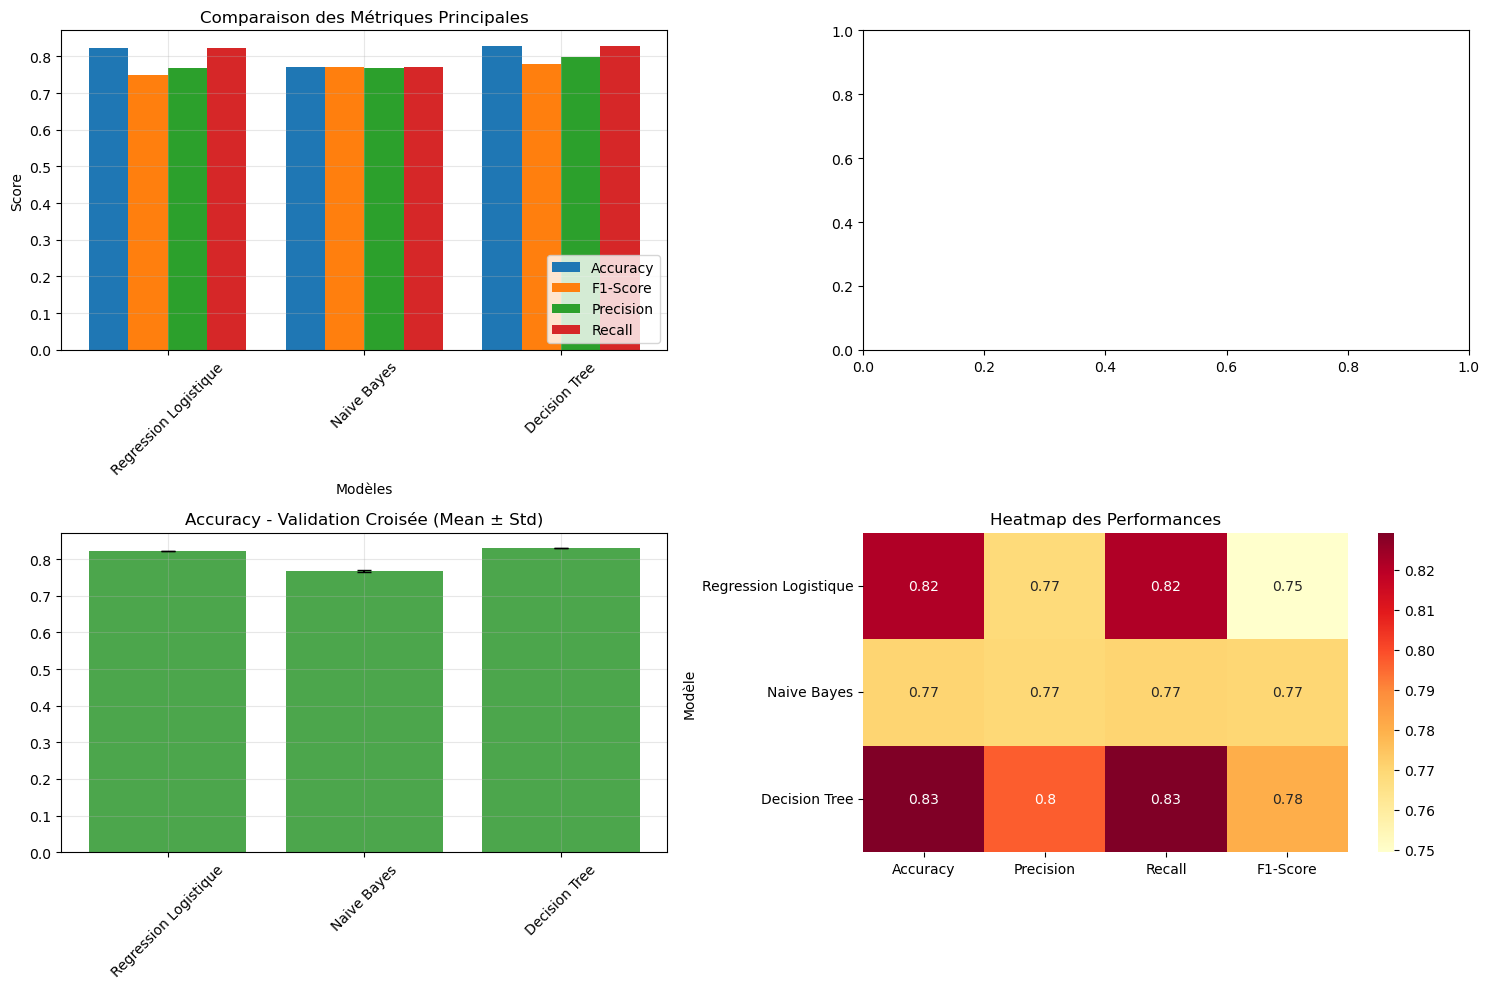

📊 TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.821400,0.768700,0.821400,0.749400,0.821700,0.000200
1,Naive Bayes,0.770400,0.769300,0.770400,0.769900,0.767900,0.002000
2,Decision Tree,0.829300,0.797000,0.829300,0.780300,0.830500,0.000600


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.8214,0.7687,0.8214,0.7494,0.8217,0.0002
1,Naive Bayes,0.7704,0.7693,0.7704,0.7699,0.7679,0.0020
2,Decision Tree,0.8293,0.7970,0.8293,0.7803,0.8305,0.0006


In [926]:
visualiser_resultats(df_scores)

# **Application PCA pour la reduction des predicteurs**

## **Definir la courbe du coude**

In [928]:
from sklearn.decomposition import PCA
from bokeh.plotting import figure ,show,output_notebook

output_notebook()

# on créera le model sans specifier le nombre de composants
pca1 = PCA()
X_resultat1 = pca1.fit(df_X).transform(df_X)

variance_explique = pca1.explained_variance_ratio_
print('variance explique : ',variance_explique)

print(pca1.components_)

# id du composant
comp_id = [1,2,3,4,5,6,7,8,9] 

p_pca1 = figure(title='compsantes principales',tools='',x_axis_label='Principal Composant',y_axis_label='variance Explique')
p_pca1.line(comp_id,variance_explique,color='red')
show(p_pca1)

Loading BokehJS ...

variance explique :  [9.86683825e-01 1.06455210e-02 1.58637371e-03 8.73511326e-04
 1.79817239e-04 2.56896651e-05 4.00423919e-06 1.25819552e-06]
[[ 3.96565183e-04  2.34517299e-05  1.39398183e-03 -9.12958855e-03
   5.29474145e-03 -8.18336316e-05 -5.08822359e-04  9.99943123e-01]
 [-1.78526933e-02  1.68192066e-03  2.17298816e-02  1.07426812e-01
   9.93775412e-01  3.09274698e-03 -6.93202901e-03 -4.30779111e-03]
 [-5.57741159e-01  2.95839447e-03  2.22000828e-02  8.20354756e-01
  -9.96742062e-02  1.67620138e-03 -7.37344103e-02  8.17049954e-03]
 [ 8.13853642e-01  7.50969862e-03 -9.13466130e-02  5.60691534e-01
  -4.31991945e-02  3.37987927e-03  1.13850383e-01  5.21052752e-03]
 [ 9.15190662e-02  8.68924699e-03  9.94782477e-01  3.08896374e-02
  -2.35489157e-02 -1.21559687e-02 -1.72927648e-02 -1.02636274e-03]
 [-4.65387014e-03  5.29039512e-03  1.31340846e-02 -3.32590155e-03
  -2.92771719e-03  9.99456959e-01  2.90516426e-02  6.51252336e-05]
 [-1.33595787e-01  5.17584479e-02  2.88321829e-02 -2.36312

## **essayons de prendre nombre de composant 4 comme la courbe coude le présente**

In [934]:
# on créera le model sans specifier le nombre de composants
pca1 = PCA(n_components=2)
df_PCA = pca1.fit(df_X).transform(df_X)

In [936]:
df_PCA

array([[-768.26732305,   36.70569344],
       [-768.26732305,   36.70569344],
       [-768.26732305,   36.70569344],
       ...,
       [ 656.4493281 ,  -39.45147168],
       [ 656.4493281 ,  -39.45147168],
       [ 656.4493281 ,  -39.45147168]])

## **Application des alogorithme**

In [938]:
df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_PCA, df_y, test_size=0.3, random_state=42, cv=5)

--> Entraînement de Regression Logistique...
 <#> Regression Logistique terminé - Accuracy: 0.8212
--> Entraînement de Naive Bayes...
 <#> Naive Bayes terminé - Accuracy: 0.8212
--> Entraînement de Decision Tree...
 <#> Decision Tree terminé - Accuracy: 0.8230


In [411]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.8292,0.7450,0.8292,0.7848,0.8288,0.0006
1,Naive Bayes,0.8154,0.7322,0.8154,0.7716,0.8146,0.0007
2,KNN,0.9464,0.9446,0.9464,0.9450,0.9420,0.0004
3,Decision Tree,0.8268,0.8044,0.8268,0.7853,0.8254,0.0005


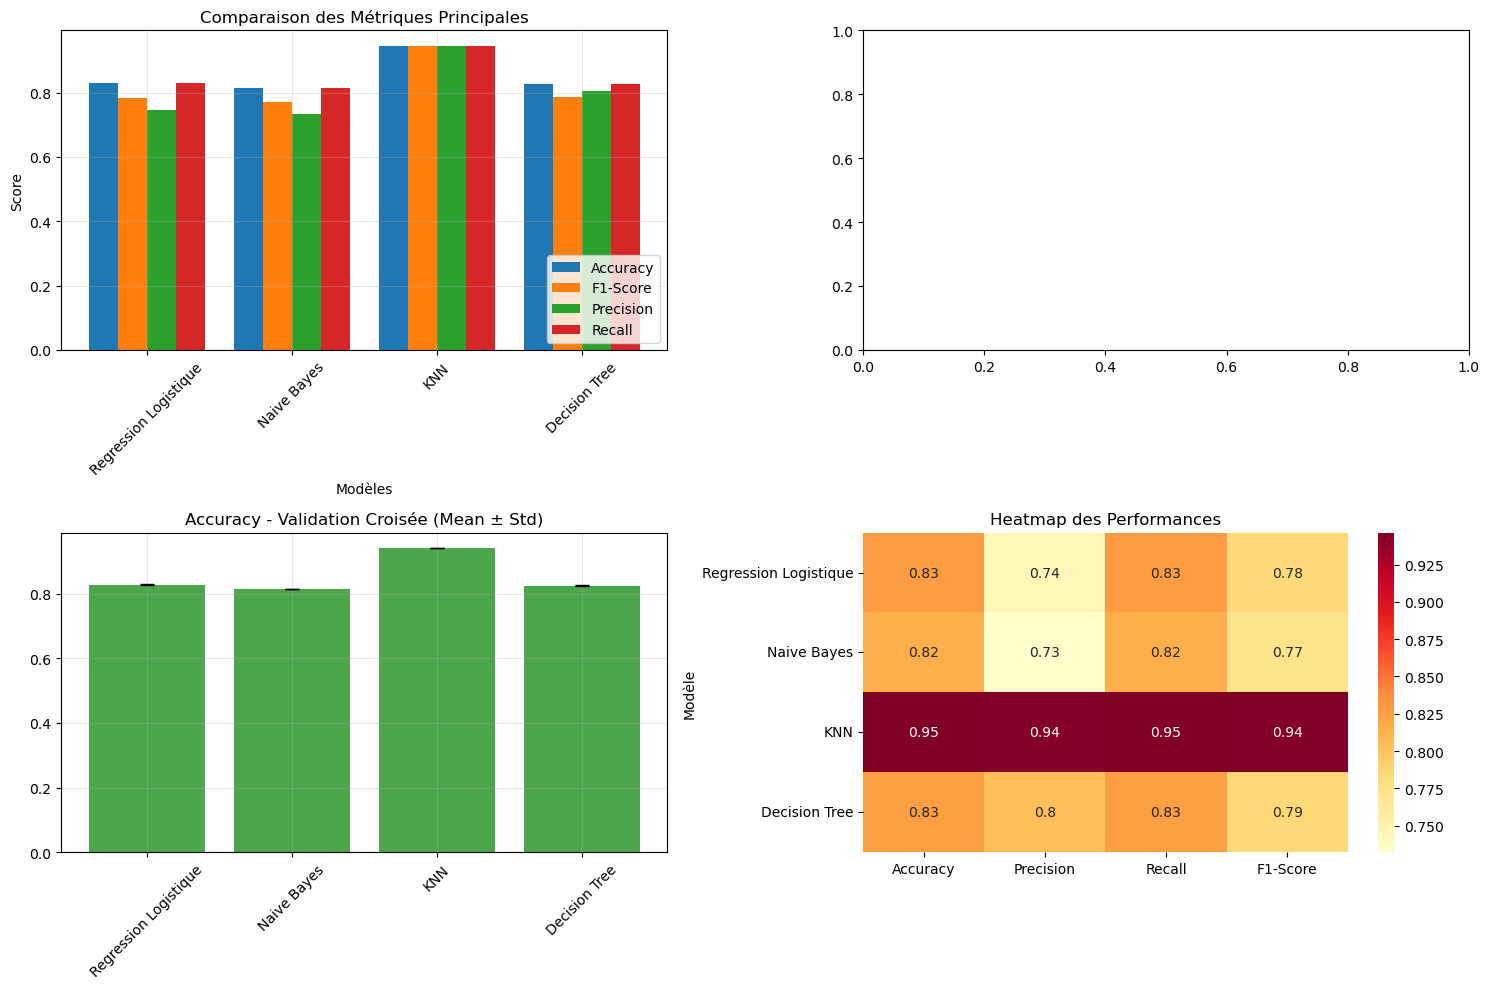

📊 TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.829200,0.745000,0.829200,0.784800,0.828800,0.000600
1,Naive Bayes,0.815400,0.732200,0.815400,0.771600,0.814600,0.000700
2,KNN,0.946400,0.944600,0.946400,0.945000,0.942000,0.000400
3,Decision Tree,0.826800,0.804400,0.826800,0.785300,0.825400,0.000500


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.8292,0.7450,0.8292,0.7848,0.8288,0.0006
1,Naive Bayes,0.8154,0.7322,0.8154,0.7716,0.8146,0.0007
2,KNN,0.9464,0.9446,0.9464,0.9450,0.9420,0.0004
3,Decision Tree,0.8268,0.8044,0.8268,0.7853,0.8254,0.0005


In [412]:
visualiser_resultats(df_scores)

# **Analyse des résultat**

- **Analyse de la Distribution Cible**
  - Classe 1 nombre de passager [0-5]   : faible ----- > 73.2% du dataset
  - Classe 2 nombre de passager [6-9]   : moyen  ----- > 16.4% du dataset
  - Classe 3 nombre de passager [10-27] : faible ----- > 10.2% du dataset
- ----------------------------------------------------------------------
  ***La classe 1 est trés majoritaire par rapport au classe 2 et 3 ceci dit qu'au moment de split on pourra fortement avoir des données seulement de la classe 1 pour le jeux de donnée d'entrainement au de tests***  
- **Accuracy est trompeuse :** Un modele naif qui prédit toujours la classe 1 a une accuracy de 73% , notre modele est a 77% ce qui donne que 4% de mieux
- ***Decision Tree le Meilleur Modèle***
  - **Recall 0.7847** : Quand il ya de l'achanladage dans la piste, je la detecte 78% du temps
  - **Precision 0.7039** : quand je prédit achalendage fort, j'ai raison a 70% du temps
    - Ce que signifie : qu'il rate 22% des cas fort achalendé, et se trompe a 30% du temps
- **Regression Logestique : Precision = 0.68.50***
  - Si le modele nous prédit piste achalendé demain dans 31,5% des cas il a tord
- ***KNN : F1-Scroe = 0.7490***
  -  le modele le plus fiable pour le moment, il detecte le mieux l'achanlendage sans les faux positives
  

***INTERPRÉTATION DES MÉTRIQUES***
- ***Cas 1*** : Recall Élevé + Précision Faible
  - → Je detecte presque tout, mais je fais beaucoup de fausses alertes
  - → Utile si : on manque beaucoup un fort achalendage nous coûte très cher
----------------------
- ***Cas 2*** : Précision Élevée + Rappel Faible
  - → Quand on prédit, on a raison, mais on prédit rarement
  - → Utile si : les fausses alertes coûtent très cher
----------------------
- ***Cas 3*** : F1-score Élevé (KNN)
  - → Bon équilibre entre détection et fiabilité
  - → Utile pour : la plupart des applications pratiques
- 

- ***SITUATION RÉELLE*** Avec les chiffres (C1=568k / C2=127k / C3=79k) :
  - ***Le modèles actuels***
    - Prédit l'achalendage faible (73% du temps)
    - Deviennent un experts pour la detection des pistes a faible achalendage
    - Mais paniquent quand ils ya des piste plus achalendé

  - ***Résultat*** : soit que le modele ratent complètement prédiction (mauvais rappel), soit qu'il a fauds positives (mauvaise précision)

- ***On doit absolument rééquilibrer les données !***

# **On va essayer de refaire l'échantillonage**

In [762]:
df = pd.read_csv("Trafic_velo.csv")
df.sample(10)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code
168688,0.0,-7.9,0.0,23.6,69.0,91.0,3,2,1425.0,23,4,8
149923,0.0,-9.1,0.0,4.6,76.0,100.0,6,2,0.0,0,1,1
183926,0.0,-13.7,0.0,19.9,70.0,90.0,1,2,90.0,1,1,1
110419,0.0,-11.5,0.0,3.9,74.0,100.0,2,1,1035.0,17,3,6
150211,0.0,-9.3,0.0,6.4,79.0,100.0,6,2,105.0,1,1,1
571255,0.0,21.5,0.0,12.0,74.0,16.0,3,6,75.0,1,1,1
236256,2.0,-5.2,0.0,9.8,79.0,100.0,1,3,540.0,9,1,2
254418,0.0,-4.1,0.0,16.4,85.0,100.0,6,3,570.0,9,1,3
692351,0.0,19.8,0.0,0.6,74.0,5.0,2,7,30.0,0,1,1
535065,10.0,14.0,0.0,9.2,80.0,100.0,6,5,1080.0,18,3,7


In [756]:
df.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,10.429026,5.970146,0.090785,11.060311,71.340174,67.218865,2.996701,3.975160,712.586182,11.501437,1.958458,3.958754
std,20.813004,13.603857,0.443573,5.586311,14.981997,39.935158,1.991573,2.015524,415.636310,6.921630,1.079333,2.573493
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000,1.000000,2.000000,360.000000,6.000000,1.000000,1.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000,3.000000,4.000000,720.000000,12.000000,2.000000,4.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000,5.000000,6.000000,1080.000000,18.000000,3.000000,7.000000
max,434.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,23.000000,4.000000,8.000000


In [764]:
df_v3 = df.copy()
df_v3 = df_v3[df_v3['nb_passages'] >0 ]

In [768]:

Q1 = df_v3['nb_passages'].quantile(0.25)
Q3 = df_v3['nb_passages'].quantile(0.75)
IQR = Q3 - Q1

# Définir les limites
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print('borne_basse : ',borne_basse)
print('borne_haute : ',borne_haute)

# Filtrer les données sans outliers
df_v3 = df_v3[(df_v3['nb_passages'] >= borne_basse) & (df_v3['nb_passages'] <= borne_haute)]

# Limiter les valeurs (winsorizing)
#df_v3['nb_passages'] = np.where(df_v3['nb_passages'] < borne_basse, borne_basse, df_v3['nb_passages'])
#df_v3['nb_passages'] = np.where(df_v3['nb_passages'] > borne_haute, borne_haute, df_v3['nb_passages'])

df_v3.head(10)

borne_basse :  -17.5
borne_haute :  34.5


,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code
4,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
11,24.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
13,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
14,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
20,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
21,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
23,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
27,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
28,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
29,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1


0     15676
1     13254
2     10870
3      9233
4      9265
5     14268
6     19557
7     20435
8     18879
9     21037
10    21743
11    21528
12    21107
13    21162
14    20998
15    20476
16    19006
17    18083
18    18966
19    19450
20    19408
21    19413
22    18979
23    17922
Name: count, dtype: int64


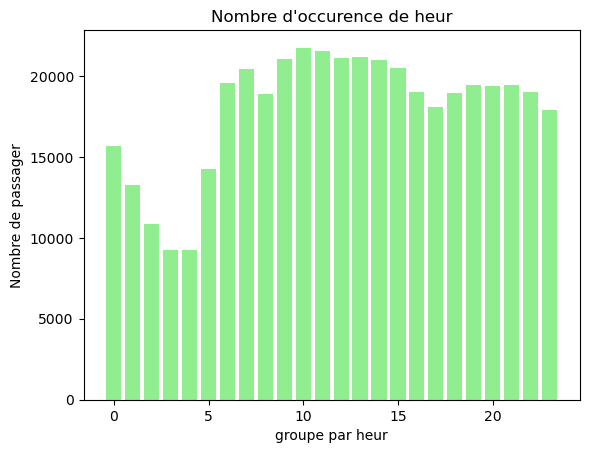

In [770]:

#df_gr = df_v3.groupby('nb_passages')['nb_passages'].count()
#df_gr.head(30)
#plt.bar(df_gr['nb_passages'], df_gr['nb_passages'], color='skyblue')
df_gr = df_v3.groupby('h').size().reset_index(name='count')
print(df_gr['count'].head(30))

plt.bar(df_gr['h'], df_gr['count'], color='lightgreen')

plt.title("Nombre d'occurence de heur")
plt.xlabel("groupe par heur")
plt.ylabel("Nombre de passager")

plt.show()


0     81943
1     53151
2     38547
3     29918
4     24536
5     20379
6     17246
7     14894
8     13072
9     11507
10    10272
11     9399
12     8472
13     7811
14     7491
15     6675
16     6217
17     5951
18     5590
19     5193
20     4835
21     4801
22     4440
23     4348
24     4112
25     3931
26     3770
27     3532
28     3489
29     3255
Name: count, dtype: int64


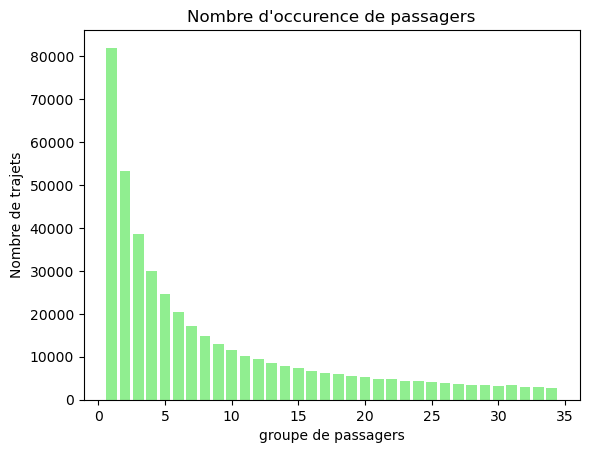

In [772]:
#df_gr = df_v3.groupby('nb_passages')['nb_passages'].count()
#df_gr.head(30)
#plt.bar(df_gr['nb_passages'], df_gr['nb_passages'], color='skyblue')
df_gr = df_v3.groupby('nb_passages').size().reset_index(name='count')
print(df_gr['count'].head(30))

plt.bar(df_gr['nb_passages'], df_gr['count'], color='lightgreen')

plt.title("Nombre d'occurence de passagers")
plt.xlabel("groupe de passagers")
plt.ylabel("Nombre de trajets")

plt.show()

- ***Stratégie :***
  - Éliminer la classe des zéro
  - redimentionner les intervals de tel sorte a obtenir une meilleurs distribution
--------------------------------------

## ***Encodage target***

- Création des groupes d'achanlendage en eliminant la classe zéro :
  - [ 1 , 1 ]    ----> **C1 - tres faible** achalendage
  - [ 2 , 3 ]    ---->  **C2 - assez faible** achalendage 
  - [ 4 , 7 ]    ---->   **C3 - faible** achalendage
  - [ 8 , 15 ]   --->   **C4 - moyen** achalendage
  - [ 16 , 26 ]  -->   **C5 - moins fort** achalendage
  - [ 27 , 28 ]  -->   **C6 - fort** achalendage


In [774]:
df_v3.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code
count,430715.000000,430715.000000,430715.000000,430715.000000,430715.000000,430715.000000,430715.000000,430715.000000,430715.000000,430715.000000,430715.000000,430715.000000
mean,8.435959,7.914133,0.094708,10.844849,70.675454,66.898559,2.995331,4.228861,761.279036,12.313495,2.029681,4.223630
std,8.493258,12.709194,0.462757,5.446326,14.990516,40.019415,1.979742,1.936816,391.678188,6.522345,1.072224,2.476717
min,1.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,-1.700000,0.000000,6.900000,62.000000,25.000000,1.000000,3.000000,450.000000,7.000000,1.000000,2.000000
50%,5.000000,9.100000,0.000000,10.200000,73.000000,94.000000,3.000000,4.000000,765.000000,12.000000,2.000000,4.000000
75%,12.000000,18.700000,0.000000,14.000000,82.000000,100.000000,5.000000,6.000000,1095.000000,18.000000,3.000000,7.000000
max,34.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,23.000000,4.000000,8.000000


In [856]:

df_split = df_v3.copy()
bins = [0,2,6,14, np.inf]
labels = ['C1', 'C2', 'C3','C4']
df_split['Etat_Circulation'] = pd.cut(df_v3['nb_passages'], bins=bins, labels=labels, include_lowest=True)

print(f"Distribution des catégories:")
print(df_split['Etat_Circulation'].value_counts())


Distribution des catégories:
Etat_Circulation
C1    135094
C2    113380
C3     92673
C4     89568
Name: count, dtype: int64


In [858]:
df_v3.sample(5)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code
101827,3.0,-2.7,0.0,24.7,77.0,100.0,0,1,690.0,11,2,4
479888,4.0,10.2,0.0,10.6,85.0,100.0,5,5,600.0,10,1,3
341900,1.0,-5.2,0.0,7.4,42.0,11.0,2,4,540.0,9,1,2
254946,3.0,-0.8,0.0,16.7,75.0,95.0,6,3,780.0,13,2,4
428672,2.0,7.8,0.0,9.5,86.0,100.0,5,4,360.0,6,1,1


In [814]:
"""
df_split = df_v3.copy()
bins = [0,5, np.inf]
labels = ['C1', 'C2']
df_split['Etat_Circulation'] = pd.cut(df_v3['nb_passages'], bins=bins, labels=labels, include_lowest=True)

print(f"Distribution des catégories:")
print(df_split['Etat_Circulation'].value_counts())
"""

Distribution des catégories:
Etat_Circulation
C1    228095
C2    202620
Name: count, dtype: int64


In [804]:
df_split.sample(5)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_0,periode_code,Etat_Circulation
742745,10.0,20.3,0.0,3.4,59.0,1.0,1,7,1215.0,20,3,7,C2
517753,1.0,10.1,0.0,8.0,79.0,100.0,1,5,1260.0,21,4,8,C1
335680,5.0,13.4,0.0,17.6,82.0,100.0,0,3,975.0,16,2,5,C1
504620,5.0,15.0,0.0,3.8,94.0,89.0,5,5,285.0,4,1,1,C1
268799,13.0,-12.2,0.0,8.8,78.0,66.0,3,3,495.0,8,1,2,C2


In [860]:
# drop columns

df_split = df_split.drop(columns=['nb_passages','h','periode_code','periode_code_0'])
#df_split = df_split.drop(columns=['nb_passages','minutes','periode_code_0','h','heure'])

df_split.sample(5)


,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,Etat_Circulation
649040,18.5,0.0,3.5,47.0,96.0,3,6,1365.0,C2
527182,9.9,0.0,13.7,75.0,100.0,4,5,765.0,C4
645048,26.1,0.0,14.0,25.0,98.0,2,6,1185.0,C4
12956,-12.5,0.0,18.2,67.0,95.0,5,1,480.0,C1
626987,22.1,0.0,18.3,46.0,12.0,4,6,1065.0,C3


In [862]:

df_split.sample(5)

,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,Etat_Circulation
766652,27.6,0.0,7.6,57.0,79.0,1,7,735.0,C4
494709,22.3,0.0,3.9,61.0,1.0,2,5,690.0,C4
10253,-6.0,0.0,17.3,66.0,100.0,4,1,900.0,C3
617368,19.8,0.0,12.3,83.0,96.0,2,6,45.0,C1
752293,22.6,0.0,10.9,78.0,100.0,4,7,675.0,C4


In [864]:

df_X = df_split.drop(columns=['Etat_Circulation']) # descripteur
df_y = df_split['Etat_Circulation']      # target

print(df_X.shape)
print(df_y.shape)


(430715, 8)
(430715,)


In [866]:
# Execution de la comparaison
#-----------------------------------

df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_X, df_y, test_size=0.25, random_state=42, cv=5)


--> Entraînement de Regression Logistique...
 <#> Regression Logistique terminé - Accuracy: 0.4226
--> Entraînement de Naive Bayes...
 <#> Naive Bayes terminé - Accuracy: 0.4151
--> Entraînement de Decision Tree...
 <#> Decision Tree terminé - Accuracy: 0.4476


In [736]:
df_split.head(10)

,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,periode_code,Etat_Circulation
4,0.9,0.0,10.4,88.0,98.0,2,1,1,C1
11,0.9,0.0,10.4,88.0,98.0,2,1,1,C2
13,0.9,0.0,10.4,88.0,98.0,2,1,1,C1
14,0.9,0.0,10.4,88.0,98.0,2,1,1,C1
20,0.9,0.0,10.4,88.0,98.0,2,1,1,C1
21,0.9,0.0,10.4,88.0,98.0,2,1,1,C1
23,0.9,0.0,10.4,88.0,98.0,2,1,1,C1
27,0.9,0.0,10.4,88.0,98.0,2,1,1,C1
28,0.9,0.0,10.4,88.0,98.0,2,1,1,C1
29,0.9,0.0,10.4,88.0,98.0,2,1,1,C1


In [722]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.7073,0.7074,0.7073,0.7073,0.7072,0.0012
1,Naive Bayes,0.7009,0.7014,0.7009,0.7007,0.7001,0.0009
2,KNN,0.7387,0.7389,0.7387,0.7386,0.7378,0.0013
3,Decision Tree,0.7400,0.7425,0.7400,0.7394,0.7381,0.0006


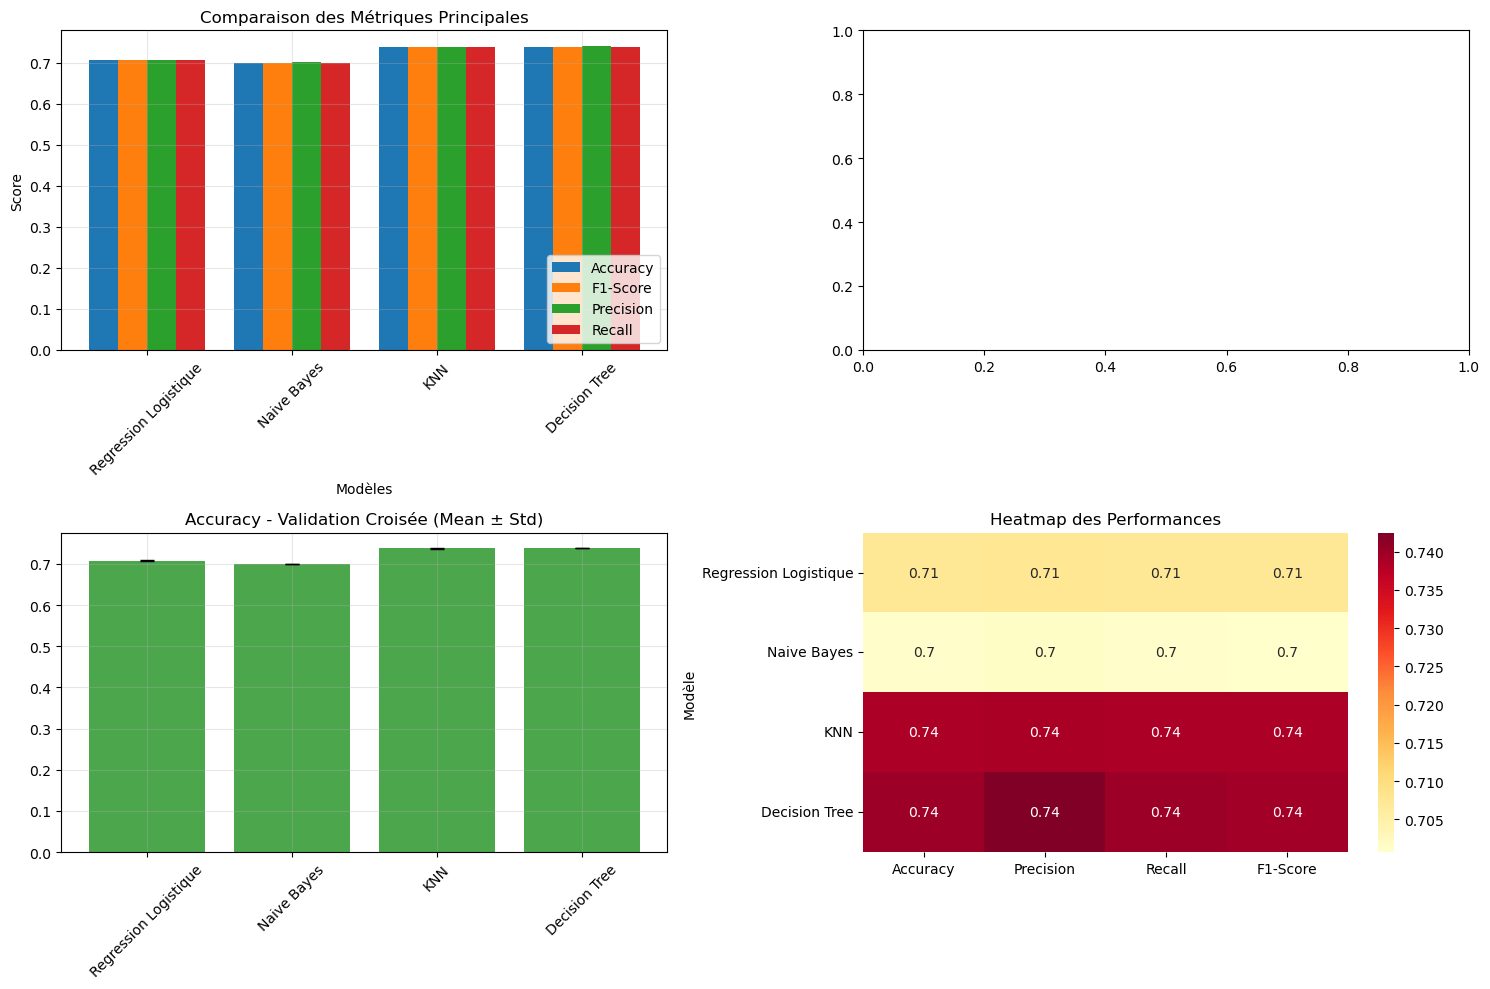

📊 TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.707300,0.707400,0.707300,0.707300,0.707200,0.001200
1,Naive Bayes,0.700900,0.701400,0.700900,0.700700,0.700100,0.000900
2,KNN,0.738700,0.738900,0.738700,0.738600,0.737800,0.001300
3,Decision Tree,0.740000,0.742500,0.740000,0.739400,0.738100,0.000600


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.7073,0.7074,0.7073,0.7073,0.7072,0.0012
1,Naive Bayes,0.7009,0.7014,0.7009,0.7007,0.7001,0.0009
2,KNN,0.7387,0.7389,0.7387,0.7386,0.7378,0.0013
3,Decision Tree,0.7400,0.7425,0.7400,0.7394,0.7381,0.0006


In [723]:
import seaborn as sns
visualiser_resultats(df_scores)